# Experimento 6: CLIP + DINOv2 + metadata limpia
**Estrategia:** Concatenar CLIP (768) + DINOv2 (1024) + metadata clínica → cabeza lineal  
**Dataset:** PAD-UFES-20 — clasificación binaria (maligno vs benigno)  
**Nota:** Esta es la fusión triple — base para la propuesta final de la tesis

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Dispositivo: cuda
GPU: Tesla T4


## 1. Cargar embeddings y labels

In [3]:
BASE_PATH    = '/content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20'
RESULTS_PATH = os.path.join(BASE_PATH, 'resultados')

clip_train = np.load(os.path.join(RESULTS_PATH, 'clip_X_train.npy'))
clip_val   = np.load(os.path.join(RESULTS_PATH, 'clip_X_val.npy'))
clip_test  = np.load(os.path.join(RESULTS_PATH, 'clip_X_test.npy'))

dino_train = np.load(os.path.join(RESULTS_PATH, 'dino_X_train.npy'))
dino_val   = np.load(os.path.join(RESULTS_PATH, 'dino_X_val.npy'))
dino_test  = np.load(os.path.join(RESULTS_PATH, 'dino_X_test.npy'))

y_train = np.load(os.path.join(RESULTS_PATH, 'y_train.npy'))
y_val   = np.load(os.path.join(RESULTS_PATH, 'y_val.npy'))
y_test  = np.load(os.path.join(RESULTS_PATH, 'y_test.npy'))

print(f'CLIP: {clip_train.shape} | DINOv2: {dino_train.shape} | Labels: {y_train.shape}')

CLIP: (1838, 768) | DINOv2: (1838, 1024) | Labels: (1838,)


## 2. Preprocesamiento de metadata clínica

In [4]:
df_train = pd.read_csv(os.path.join(BASE_PATH, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(BASE_PATH, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(BASE_PATH, 'split_test.csv'))

META_COLS = [
    'smoke', 'drink', 'pesticide', 'gender',
    'skin_cancer_history', 'cancer_history',
    'has_piped_water', 'has_sewage_system',
    'age', 'fitspatrick', 'diameter_1', 'diameter_2',
    'region', 'background_father', 'background_mother',
    'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation'
]
NUM_COLS = ['age', 'fitspatrick', 'diameter_1', 'diameter_2']
CAT_COLS = [c for c in META_COLS if c not in NUM_COLS]

def preprocess_metadata(df_train, df_val, df_test, meta_cols, num_cols, cat_cols):
    tr = df_train[meta_cols].copy()
    va = df_val[meta_cols].copy()
    te = df_test[meta_cols].copy()

    scaler = MinMaxScaler()
    tr[num_cols] = scaler.fit_transform(tr[num_cols])
    va[num_cols] = scaler.transform(va[num_cols])
    te[num_cols] = scaler.transform(te[num_cols])

    for df in [tr, va, te]:
        for col in df.select_dtypes(include='bool').columns:
            df[col] = df[col].astype(int)

    string_cats = [c for c in cat_cols if tr[c].dtype == object]
    tr_enc = pd.get_dummies(tr, columns=string_cats)
    va_enc = pd.get_dummies(va, columns=string_cats)
    te_enc = pd.get_dummies(te, columns=string_cats)

    va_enc = va_enc.reindex(columns=tr_enc.columns, fill_value=0)
    te_enc = te_enc.reindex(columns=tr_enc.columns, fill_value=0)

    return tr_enc.values.astype(np.float32), va_enc.values.astype(np.float32), te_enc.values.astype(np.float32)

M_train, M_val, M_test = preprocess_metadata(df_train, df_val, df_test, META_COLS, NUM_COLS, CAT_COLS)
print(f'Metadata: {M_train.shape}')

Metadata: (1838, 69)


## 3. Fusión triple: CLIP ∥ DINOv2 ∥ metadata

In [5]:
X_train = np.concatenate([clip_train, dino_train, M_train], axis=1)
X_val   = np.concatenate([clip_val,   dino_val,   M_val],   axis=1)
X_test  = np.concatenate([clip_test,  dino_test,  M_test],  axis=1)

print(f'Dimensión total: 768 (CLIP) + 1024 (DINOv2) + {M_train.shape[1]} (metadata) = {X_train.shape[1]}')

Dimensión total: 768 (CLIP) + 1024 (DINOv2) + 69 (metadata) = 1861


## 4. DataLoaders

In [6]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=64, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=64, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=64, shuffle=False
)
print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 29 | Val: 4 | Test: 4


## 5. Cabeza lineal

In [7]:
input_dim = X_train.shape[1]

head = nn.Sequential(
    nn.Linear(input_dim, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 1)
).to(device)

trainable = sum(p.numel() for p in head.parameters())
print(f'Input dim: {input_dim} | Parámetros entrenables: {trainable:,}')

Input dim: 1861 | Parámetros entrenables: 1,084,929


## 6. Entrenamiento

In [8]:
EPOCHS    = 30
LR        = 1e-3
THRESHOLD = 0.5
PATIENCE  = 10

criterion       = nn.BCEWithLogitsLoss()
optimizer       = torch.optim.Adam(head.parameters(), lr=LR, weight_decay=1e-4)
scheduler       = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
best_val_auc    = 0
patience_count  = 0
best_model_path = os.path.join(RESULTS_PATH, 'clip_dino_meta_head.pt')
history         = {'train_loss': [], 'val_loss': [], 'val_auc': []}

for epoch in range(EPOCHS):
    head.train()
    train_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(head(X_b).squeeze(1), y_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    head.eval()
    val_loss, val_probs, val_labels = 0, [], []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out       = head(X_b).squeeze(1)
            val_loss += criterion(out, y_b).item()
            val_probs.extend(torch.sigmoid(out).cpu().numpy())
            val_labels.extend(y_b.cpu().numpy())
    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(val_labels, val_probs)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    print(f'Epoch {epoch+1:02d} | Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(head.state_dict(), best_model_path)
        patience_count = 0
        print(f'Mejor modelo (AUC={best_val_auc:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping epoch {epoch+1}')
            break

print(f'\nMejor Val AUC: {best_val_auc:.4f}')

Epoch 01 | Loss: 0.4110 | Val Loss: 0.2610 | Val AUC: 0.9643
Mejor modelo (AUC=0.9643)
Epoch 02 | Loss: 0.2489 | Val Loss: 0.2309 | Val AUC: 0.9727
Mejor modelo (AUC=0.9727)
Epoch 03 | Loss: 0.2229 | Val Loss: 0.2784 | Val AUC: 0.9749
Mejor modelo (AUC=0.9749)
Epoch 04 | Loss: 0.2148 | Val Loss: 0.2328 | Val AUC: 0.9704
Epoch 05 | Loss: 0.2256 | Val Loss: 0.2239 | Val AUC: 0.9701
Epoch 06 | Loss: 0.1793 | Val Loss: 0.2157 | Val AUC: 0.9699
Epoch 07 | Loss: 0.1603 | Val Loss: 0.2332 | Val AUC: 0.9671
Epoch 08 | Loss: 0.1379 | Val Loss: 0.2235 | Val AUC: 0.9679
Epoch 09 | Loss: 0.1311 | Val Loss: 0.2223 | Val AUC: 0.9690
Epoch 10 | Loss: 0.1095 | Val Loss: 0.2330 | Val AUC: 0.9684
Epoch 11 | Loss: 0.1047 | Val Loss: 0.2350 | Val AUC: 0.9677
Epoch 12 | Loss: 0.0976 | Val Loss: 0.2346 | Val AUC: 0.9706
Epoch 13 | Loss: 0.0795 | Val Loss: 0.2320 | Val AUC: 0.9700
Early stopping epoch 13

Mejor Val AUC: 0.9749


## 7. Evaluación en Test

In [9]:
head.load_state_dict(torch.load(best_model_path))
head.eval()

test_probs, test_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out = head(X_b.to(device)).squeeze(1)
        test_probs.extend(torch.sigmoid(out).cpu().numpy())
        test_labels.extend(y_b.numpy())

test_probs  = np.array(test_probs)
test_labels = np.array(test_labels)
test_preds  = (test_probs >= THRESHOLD).astype(int)

auc       = roc_auc_score(test_labels, test_probs)
accuracy  = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall    = recall_score(test_labels, test_preds)
f1        = f1_score(test_labels, test_preds)

print('=' * 55)
print('  RESULTADOS — CLIP + DINOv2 + metadata limpia')
print('=' * 55)
print(f'  AUC-ROC   : {auc:.4f}')
print(f'  Accuracy  : {accuracy*100:.1f}%')
print(f'  Precision : {precision*100:.1f}%')
print(f'  Recall    : {recall*100:.1f}%')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 55)
print()
print(classification_report(test_labels, test_preds, target_names=['Benigno', 'Maligno']))

  RESULTADOS — CLIP + DINOv2 + metadata limpia
  AUC-ROC   : 0.9653
  Accuracy  : 88.7%
  Precision : 82.8%
  Recall    : 96.4%
  F1-Score  : 0.8908

              precision    recall  f1-score   support

     Benigno       0.96      0.82      0.88       120
     Maligno       0.83      0.96      0.89       110

    accuracy                           0.89       230
   macro avg       0.89      0.89      0.89       230
weighted avg       0.90      0.89      0.89       230



## 8. Curvas y matriz de confusión

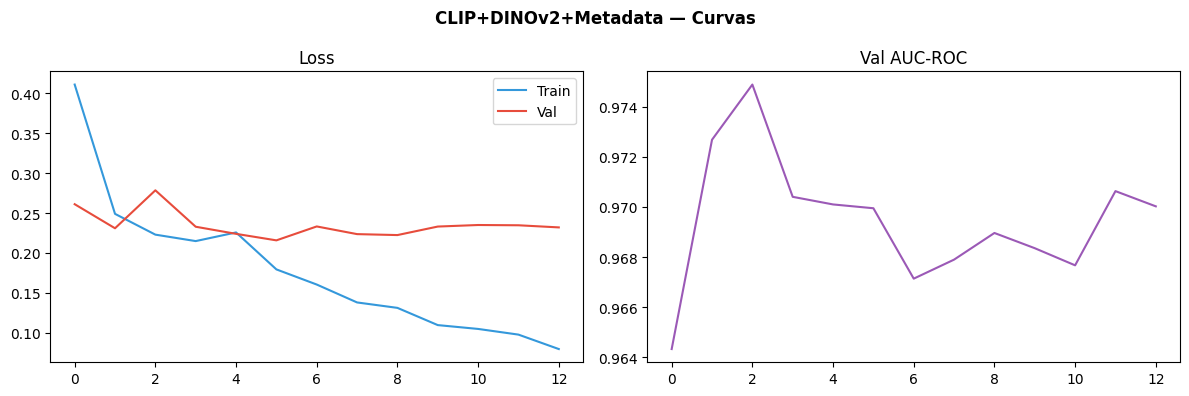

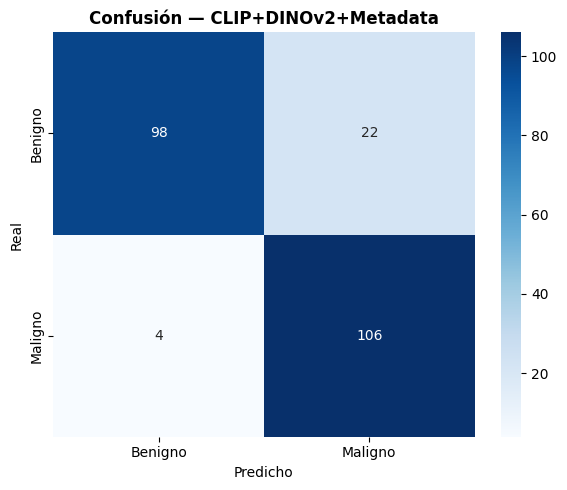

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train', color='#3498db')
axes[0].plot(history['val_loss'],   label='Val',   color='#e74c3c')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history['val_auc'], color='#9b59b6')
axes[1].set_title('Val AUC-ROC')
plt.suptitle('CLIP+DINOv2+Metadata — Curvas', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'clip_dino_meta_curvas.png'), dpi=150, bbox_inches='tight')
plt.show()

cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'], ax=ax)
ax.set_title('Confusión — CLIP+DINOv2+Metadata', fontweight='bold')
ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'clip_dino_meta_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Guardar resultados

In [11]:
results = {
    'modelo':    'CLIP+DINOv2+metadata limpia',
    'backbone':  'ViT-L/14 CLIP + ViT-L/14 DINOv2 + metadata',
    'auc':       round(auc, 4),
    'accuracy':  round(accuracy, 4),
    'precision': round(precision, 4),
    'recall':    round(recall, 4),
    'f1':        round(f1, 4),
}
results_path = os.path.join(RESULTS_PATH, 'resultados_clip_dino_meta.csv')
pd.DataFrame([results]).to_csv(results_path, index=False)
print(f'Guardado en: {results_path}')
print(pd.DataFrame([results]))

Guardado en: /content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20/resultados/resultados_clip_dino_meta.csv
                        modelo                                    backbone  \
0  CLIP+DINOv2+metadata limpia  ViT-L/14 CLIP + ViT-L/14 DINOv2 + metadata   

      auc  accuracy  precision  recall      f1  
0  0.9653     0.887     0.8281  0.9636  0.8908  
